# work in progress: context_entails_answer baseline 

* do two new base runs for squad and trivia_qa with context: 171872, 171873

* show performance of context entails response baseline (which is enabled for these runs)
* also compare to previous short runs


In [1]:
%load_ext autoreload
%autoreload 2


from paper_utils import *


def get_arg_df():
    # now add the config args to both dfs
    arg_df = []
    for wandbid, config in configs.items():
        try:
            arg_df.append([wandbid] + [config[arg.replace('.', '_')] for arg in args])
        except:
            arg_df.append([wandbid] + [config[arg] for arg in args])
        
    arg_df = pd.DataFrame(arg_df, columns=['wandbid'] + ['c.' + arg for arg in args])

    unique_cols = []
    for column in arg_df.columns[1:]:
        if column == 'name':
            continue
        if len(arg_df[column].unique()) > 1:
            unique_cols += [column]
    uniq_name = 'UNIQ-' + '-'.join(unique_cols)
    arg_df[uniq_name] = arg_df.apply(
        lambda x: '-'.join([str(x[col]) for col in unique_cols]),
        axis=1)


    return arg_df, uniq_name, unique_cols

Llama-2-70b short generations with context (only trivia_qa/squad)

In [ ]:
 'tm87ugfd': 'trivia_qa-Llama-2-70b-chat-squad-deberta',


In [13]:
runs = {
    'su7uvc45': 'squad-yes_context',
    'h2w6hy24': 'trivia_qa-yes_context',
    'rtkaljty': 'squad-no_context',
    'tm87ugfd': 'trivia_qa-no_context'
}

In [14]:
all_results, all_configs = {}, {}
for wandb_id in runs:
    all_results[wandb_id], all_configs[wandb_id] = restore_file(wandb_id)

In [18]:
DeepDiff(all_configs['su7uvc45'], all_configs['h2w6hy24'])

{'values_changed': {"root['dataset']['value']": {'new_value': 'trivia_qa',
   'old_value': 'squad'},
  "root['answerable_only']['value']": {'new_value': False, 'old_value': True},
  "root['_wandb']['value']['start_time']": {'new_value': 1701266099.632955,
   'old_value': 1701266469.989095}}}

In [15]:
DeepDiff(all_configs['su7uvc45'], all_configs['rtkaljty'])

{'values_changed': {"root['experiment_lot']['value']": {'new_value': 'run_25_nov',
   'old_value': 'w_context_runs'},
  "root['use_context']['value']": {'new_value': False, 'old_value': True},
  "root['compute_context_entails_response']['value']": {'new_value': False,
   'old_value': True},
  "root['_wandb']['value']['start_time']": {'new_value': 1700932850.147799,
   'old_value': 1701266469.989095}}}

In [17]:
DeepDiff(all_configs['h2w6hy24'], all_configs['tm87ugfd'])

{'values_changed': {"root['experiment_lot']['value']": {'new_value': 'run_25_nov',
   'old_value': 'w_context_runs'},
  "root['use_context']['value']": {'new_value': False, 'old_value': True},
  "root['compute_context_entails_response']['value']": {'new_value': False,
   'old_value': True},
  "root['_wandb']['value']['start_time']": {'new_value': 1700927965.186176,
   'old_value': 1701266099.632955}}}

Diffs look great, these are the correct runs!

# Eval

model,no_context,yes_context
dataset,,
squad,0.3225,0.925
trivia_qa,0.7475,0.835


Text(0, 0.5, 'accuracy')

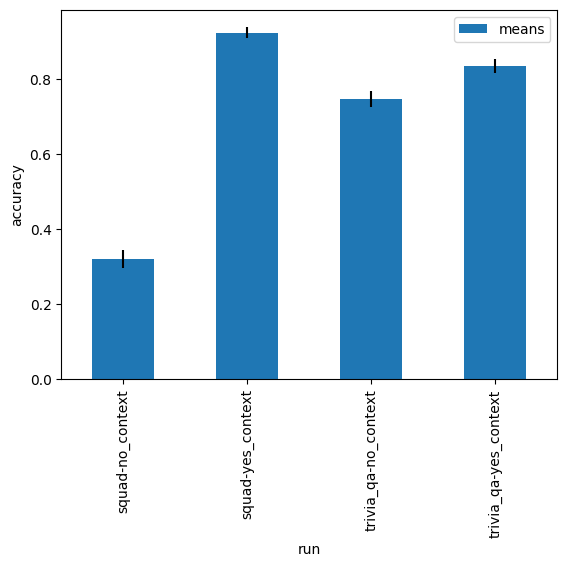

In [39]:
def get_perf_df(runs, all_results=all_results):
    perfdf = {}
    for wandb_id, run_name in runs.items():
        results = all_results[wandb_id]    
        perfdf[wandb_id] = get_perfs(results)
    
    runids = list(perfdf.keys())
    tmp = pd.DataFrame(perfdf[runids[0]])
    tmp['wandbid'] = runids[0]
    tmp['run'] = runs[runids[0]]
    
    for runid in runids[1:]:
        tmp2 = pd.DataFrame(perfdf[runid])
        tmp2['wandbid'] = runid
        tmp2['run'] = runs[runid]
        
        tmp = pd.concat([tmp, tmp2])
    
    perfdf = tmp.reset_index()
    perfdf['dataset'] = perfdf.run.map(lambda x: '-'.join(x.split('-')[:1]))
    perfdf['model'] = perfdf.run.map(lambda x: '-'.join(x.split('-')[1:]))

    tmp = perfdf.set_index('method').loc['accuracy']
    display(tmp.pivot(columns='model', index='dataset', values='means'))

    pdfs = {}
    for wandb_id in runs:
        results = all_results[wandb_id]
        pdfs[wandb_id] = get_uncertainty_df(results)
    
    runids = list(pdfs.keys())

    tmp = pd.DataFrame(pdfs[runids[0]])
    tmp['run'] = runs[runids[0]]
    tmp['wandbid'] = runids[0]
    
    for runid in runids[1:]:
        tmp2 = pd.DataFrame(pdfs[runid])
        tmp2['run'] = runs[runid]
        tmp2['wandbid'] = runid
    
        tmp = pd.concat([tmp, tmp2])
    
    all_runs = tmp.reset_index()

    return perfdf, pdfs, all_runs

perfdf, pdfs, all_runs = get_perf_df(runs)


plot_bar(perfdf.set_index('method').loc['accuracy'].set_index('run').sort_index())
plt.gca().set_ylabel('accuracy')

* context helps improve model accuracy! (especially for trivia_qa)

In [49]:
for name, gdf in perfdf.set_index('method').loc[acc].groupby(['dataset', 'model']):
    if len(gdf) > 1:
        print(name, gdf)

/auto/users/jansen/semantic_uncertainty/notebooks/paper_evals/paper_utils.py:165: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90);


Text(0, 0.5, 'accuracy')

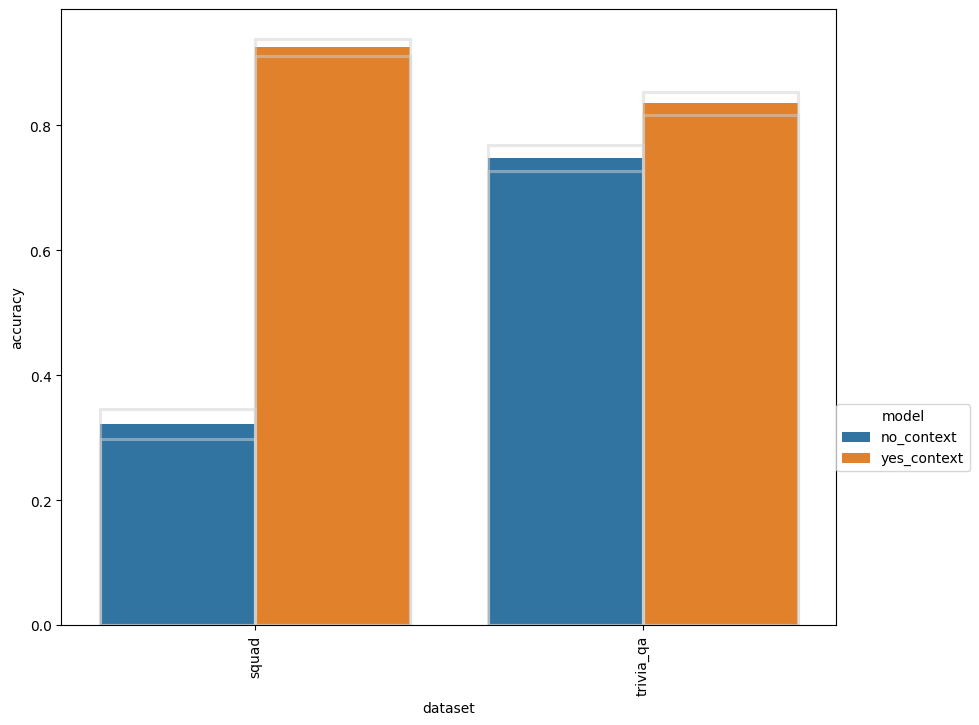

In [50]:
# just select the base entailment_model and metric, and ignore 'max_from' accuracies
acc = 'accuracy'
plot_grouped(perfdf.set_index('method').loc[acc], metric='means', x='dataset', hue='model')
plt.gca().set_ylabel(acc)

/auto/users/jansen/semantic_uncertainty/notebooks/paper_evals/paper_utils.py:165: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90);


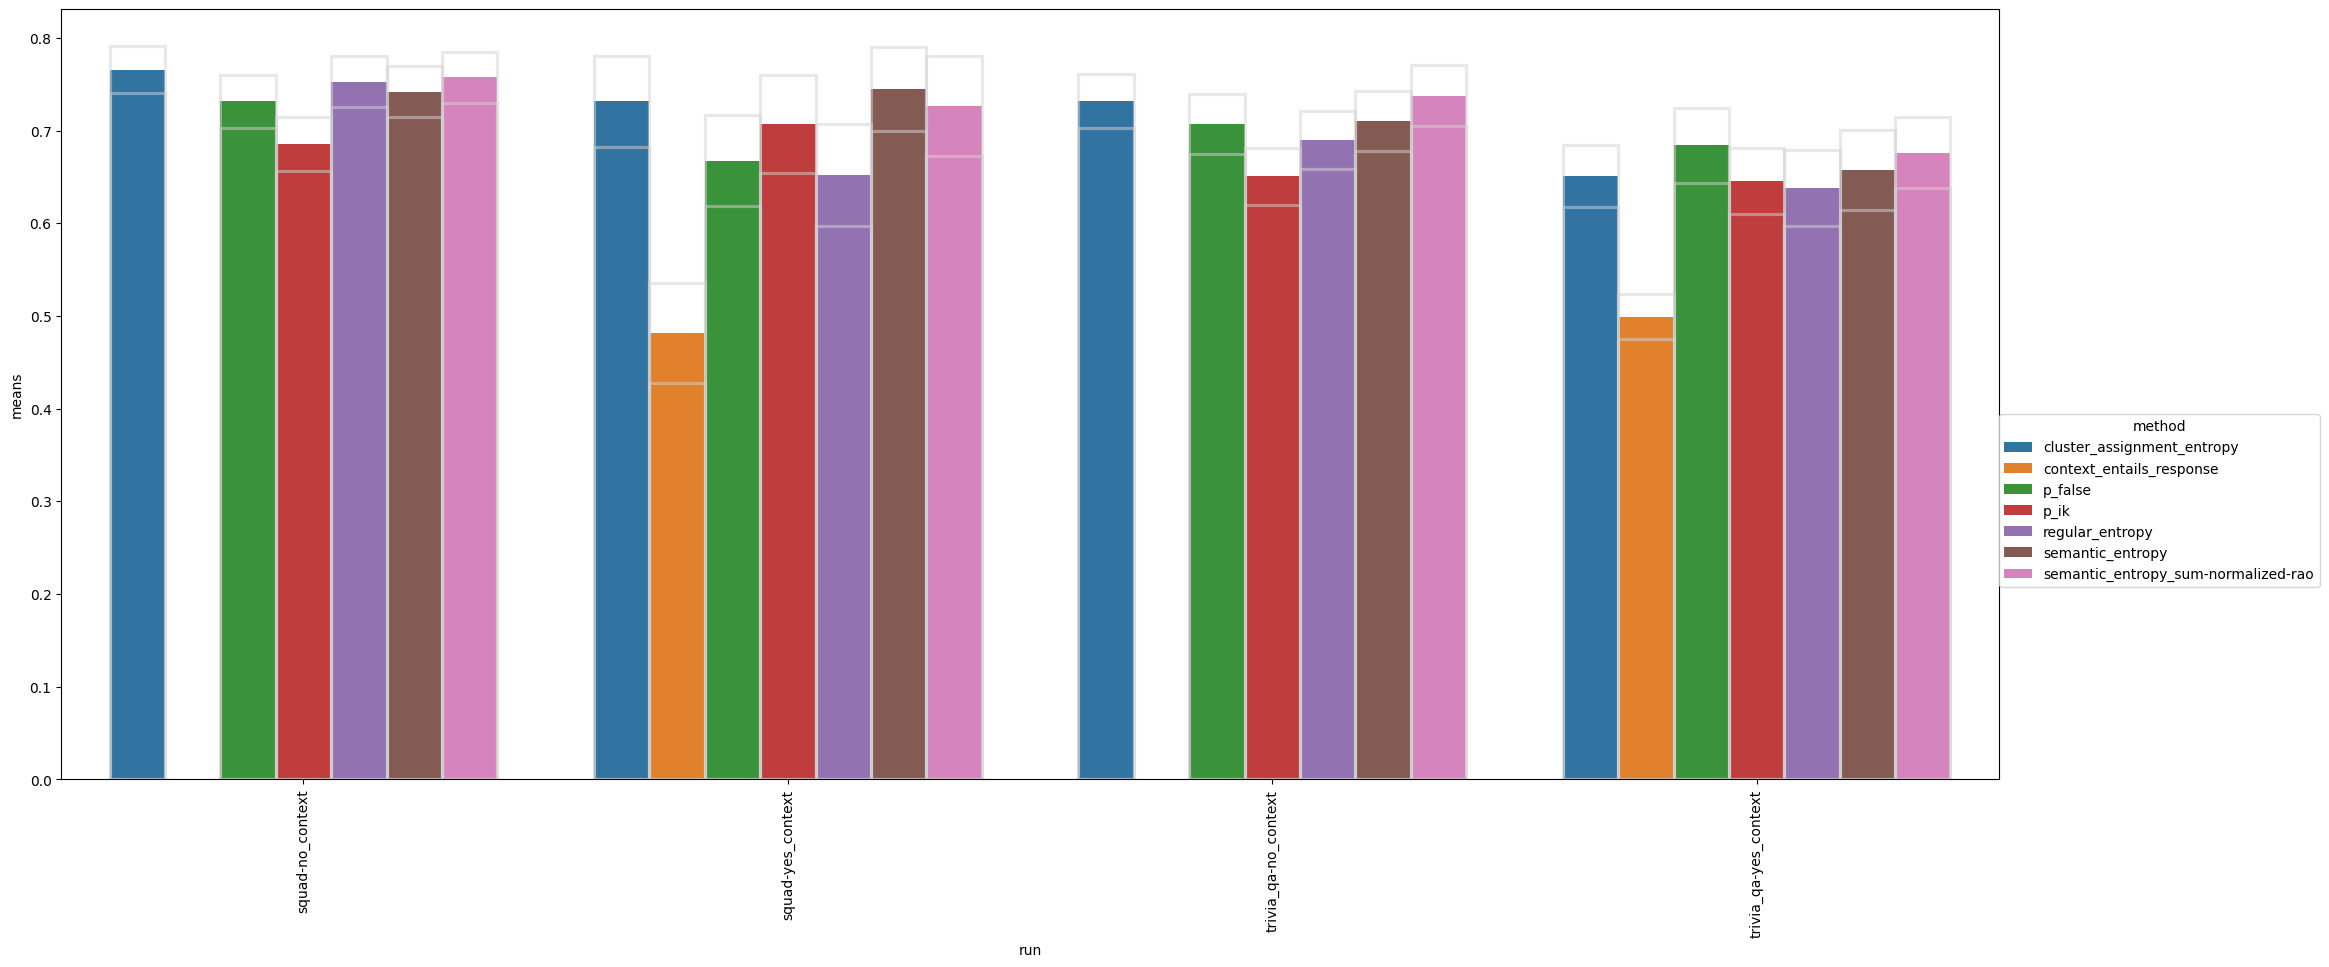

In [56]:
main_methods = ['cluster_assignment_entropy', 'regular_entropy', 'semantic_entropy', 'p_ik', 'p_false', 'semantic_entropy_sum-normalized-rao', 'context_entails_response']

plot_grouped(
    all_runs.set_index('metric').loc['AUROC'].set_index('method').loc[main_methods].reset_index(),
    metric='means', x='run', hue='method',
    figsize=(25, 10)
)

In [60]:
tmp = all_runs.set_index('metric').loc['AUROC']
tmp = tmp[tmp.method.map(lambda x: 'UNANSWERABLE' not in x)]
tmp = tmp[tmp.run.map(lambda x: 'yes_context' in x)]
tmp.groupby('method').mean('means').sort_values('means', ascending=False)

,means,low,high
method,,,
semantic_entropy_sum-normalized-rao_max_from_semantic_entropy_sum-normalized-rao,0.712796,0.668709,0.756882
semantic_entropy_max_from_semantic_entropy,0.702715,0.661052,0.744379
semantic_entropy_sum-normalized-rao,0.701238,0.655001,0.747475
semantic_entropy,0.700754,0.656571,0.744937
semantic_entropy_sum_sum-normalized-rao_max_from_semantic_entropy_sum_sum-normalized-rao,0.697146,0.653020,0.741272
semantic_entropy_cmean_max_from_semantic_entropy_cmean,0.695656,0.652614,0.738699
semantic_entropy_sum_max_from_semantic_entropy_sum,0.695010,0.654553,0.735467
semantic_entropy_sum-normalized_max_from_semantic_entropy_sum-normalized,0.693729,0.650586,0.736872
cluster_assignment_entropy,0.691274,0.650184,0.732364


In [61]:
tmp = all_runs.set_index('metric').loc['AUROC']
tmp = tmp[tmp.method.map(lambda x: 'UNANSWERABLE' not in x)]
tmp = tmp[tmp.run.map(lambda x: 'no_context' in x)]
tmp.groupby('method').mean('means').sort_values('means', ascending=False)

,means,low,high
method,,,
cluster_assignment_entropy,0.748532,0.721353,0.775710
semantic_entropy_sum-normalized-rao,0.747435,0.717211,0.777660
semantic_entropy_sum-normalized-rao_max_from_semantic_entropy_sum-normalized-rao,0.745225,0.716743,0.773707
semantic_entropy_sum_sum-normalized-rao_max_from_semantic_entropy_sum_sum-normalized-rao,0.740164,0.711505,0.768822
semantic_entropy_sum_sum-normalized-rao,0.730714,0.701649,0.759779
semantic_entropy,0.726053,0.696307,0.755799
semantic_entropy_sum_max_from_semantic_entropy_sum,0.721767,0.692582,0.750951
semantic_entropy_sum,0.721438,0.693242,0.749634
regular_entropy,0.721340,0.691865,0.750815
